In [1]:
# !pip install livelossplot --quiet

In [2]:
white, black = 1, -1
empty = 0

rows = 8
cols = 8

DIRECTIONS = [
    (-1, -1), (-1, 0), (-1, 1),
    ( 0, -1),          ( 0, 1),
    ( 1, -1), ( 1, 0), ( 1, 1)
]

In [3]:
black_chip = "●"
white_chip = "○"
empty_chip = "·"

In [4]:
import torch
import random

def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)

SEED = 116
set_seed(SEED)

In [5]:
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    !nvidia-smi
    print()
else:
    DEVICE = torch.device('cpu')
print('CPU')
!cat /proc/cpuinfo | grep 'processor\|model\ name'
print()
!python3 --version
print('torch version   :', torch.__version__)
print('use device      :', DEVICE)

Fri Aug  7 13:28:27 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             11W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [6]:
class Board:
    def __init__(self):
        self.reset()

    def reset(self):

        self.player = white
        
        self.state = [
            [empty] * cols for _ in range(rows)
        ]
        
        self.state[3][3] = white
        self.state[4][4] = white
        self.state[3][4] = black
        self.state[4][3] = black

    def encode(self):
        own = torch.zeros((rows, cols), dtype=torch.float32)
        opp = torch.zeros((rows, cols), dtype=torch.float32)

        for r in range(rows):
            for c in range(cols):
                if self.state[r][c] == self.player:
                    own[r][c] = 1.0
                if self.state[r][c] == -self.player:
                    opp[r][c] = 1.0
        return torch.stack([own, opp])

    def action_mask(self):
        moves = self.valid_moves(self.player)

        assert len(moves) > 0

        mask = torch.full((rows * cols,), float("-inf"), dtype=torch.float32)

        for row, col in moves:
            mask[row * rows + col] = 0.0
        
        return mask

    def copy(self):
        b_copy = Board()
        b_copy.player = self.player
        b_copy.state = [row[:] for row in self.state]
        return b_copy

    def render(self):
        print(f"Turn {self.player}")
        
        for line in self.state:
            for el in line:
                if el == empty:
                    print(empty_chip, end=" ")
                elif el == white:
                    print(white_chip, end=" ")
                else:
                    print(black_chip, end=" ")
            print()

    def count_score(self):
        wc, bc = 0, 0
        for line in self.state:
            for chip in line:
                if chip == empty:
                    continue
                wc, bc = (wc+1, bc) if chip == white else (wc, bc+1)
        return wc, bc

    def winner(self):
        wc, bc = self.count_score()
        if wc > bc:
            return white
        elif bc > wc:
            return black
        return empty


    def check_chip(self, curr_player, chip_coords):
    
        row, col = chip_coords
        # print(row, col, player)
    
        enemy = curr_player * -1
    
        steps = []
    
        for dr, dc in DIRECTIONS:
    
            r = row + dr
            c = col + dc
    
            # сосед должен быть противником
            if not (0 <= r < rows and 0 <= c < cols):
                continue
            
            # print(f"check: {r, c, board[r][c]}")
    
            if self.state[r][c] != enemy:
                continue
    
            # идем дальше
            while True:
    
                r += dr
                c += dc
    
                if not (0 <= r < rows and 0 <= c < cols):
                    break
                
                # print(f"check next: {r, c, board[r][c]}")
    
                if self.state[r][c] == enemy:
                    continue
    
                if self.state[r][c] == empty:
                    steps.append((r, c))
                    # print("found step place")
                    break
    
                if self.state[r][c] == curr_player:
                    break
    
        return steps

    def valid_moves(self, curr_player):
        steps = set()
        for row in range(rows):
            for col in range(cols):
                if self.state[row][col] == curr_player:
                    for step in self.check_chip(curr_player, (row, col)):
                        steps.add(step)
        return steps

    def reverse_chips(self, chips):
        for x, y in chips:
            self.state[x][y] = self.player
    
    def play(self, move):

        assert move in self.valid_moves(self.player)
        
        move_row, move_col = move

        enemy = self.player * -1
        
        all_reverses = []
    
        for dr, dc in DIRECTIONS:
    
            r = move_row
            c = move_col
    
            reverse = []
            
            while True:
    
                r += dr
                c += dc
    
                if not (0 <= r < rows and 0 <= c < cols):
                    reverse = []
                    break
    
                if self.state[r][c] == enemy:
                    reverse.append((r, c))
                    continue
    
                if self.state[r][c] == self.player:
                    break
    
                if self.state[r][c] == empty:
                    reverse = []
                    break
    
            if reverse:
                all_reverses.extend(reverse)
        
    
        if all_reverses:
            self.state[move_row][move_col] = self.player
            self.reverse_chips(all_reverses)

            self.player *= -1
            if not self.valid_moves(self.player):
                self.player *= -1
            
    
        return bool(all_reverses)

    def game_over(self):
        return not self.valid_moves(white) and not self.valid_moves(black)

In [7]:
# board = Board()
# board.encode().shape, board.action_mask().shape

In [8]:
class Node:
    def __init__(self, prior):
        self.N = 0 # 
        self.W = 0.0
        self.P = prior
        self.children = {} # dict: action -> Node
        self.board = None 

    @property
    def Q(self):
        return self.W / self.N if self.N > 0 else 0.0

    def is_expanded(self):
        return len(self.children) > 0

In [9]:
import math

class MCTS:
    def __init__(self, model, c_puct=1.5, n_simulations=200, dirichlet_alpha=0.3, dirichlet_epsilon=0.25):
        self.model = model
        self.c_puct = c_puct
        self.n_simulations = n_simulations

        self.dirichlet_alpha = dirichlet_alpha
        self.dirichlet_epsilon = dirichlet_epsilon

    def search(self, root_board):
        root = Node(prior=1.0)
        root.board = root_board.copy()
        self._expand(root)  # раскрываем корень сразу, до симуляций

        if self.dirichlet_epsilon > 0 and root.children:
            actions = list(root.children.keys())
            noise = torch.distributions.Dirichlet(
                torch.full((len(actions),), self.dirichlet_alpha)
            ).sample()
            for a, n in zip(actions, noise):
                c = root.children[a]
                c.P = (1 - self.dirichlet_epsilon) * c.P + self.dirichlet_epsilon * n.item()

        for _ in range(self.n_simulations):
            node = root
            path = [node]

            # 1. SELECTION — спускаемся, пока не дойдём до нераскрытого листа
            while node.is_expanded() and not node.board.game_over():
                action, node = self._select_child(node)
                path.append(node)

            # 2. EXPANSION + EVALUATION
            if not node.board.game_over():
                value = self._expand(node)
            else:
                value = self._terminal_value(node.board)

            # 3. BACKPROPAGATION
            self._backprop(path, value)

        return self._get_policy_target(root)

    def _select_child(self, node):
        best_score = -float('inf')
        best_action, best_child = None, None
        for action, child in node.children.items():
            score = -child.Q + self.c_puct * child.P * math.sqrt(node.N) / (1 + child.N)
            if score > best_score:
                best_score = score
                best_action, best_child = action, child
        return best_action, best_child


    def _expand(self, node):
        # FIX: тензоры нужно переносить на DEVICE, иначе при модели на GPU
        # тут вылетит RuntimeError из-за несовпадения устройств
        state = node.board.encode().unsqueeze(0).to(DEVICE)
        mask = node.board.action_mask().to(DEVICE)

        with torch.no_grad():
            policy_logits, value = self.model(state)
        policy_logits = policy_logits.squeeze(0) + mask
        probs = F.softmax(policy_logits, dim=0)

        legal_actions = node.board.valid_moves(node.board.player)
        for r, c in legal_actions:
            action = r * cols + c
            child_board = node.board.copy()
            child_board.play((r, c))
            child = Node(prior=probs[action].item())
            child.board = child_board
            node.children[action] = child

        return value.item()

    def _backprop(self, path, value):
        for node in reversed(path):
            node.N += 1
            node.W += value
            value = -value   # с точки зрения предыдущего игрока знак противоположный

    def _terminal_value(self, board):
        winner = board.winner()
        if winner == board.player:
            return 1.0
        elif winner == -board.player:
            return -1.0
        return 0.0

    def _get_policy_target(self, root):
        target = torch.zeros(rows * cols)
        total_N = sum(child.N for child in root.children.values())
        for action, child in root.children.items():
            target[action] = child.N / total_N
        return target


In [10]:
class FastMCTS:
    def __init__(self, model, c_puct=1.5, n_simulations=200, dirichlet_alpha=0.3, dirichlet_epsilon=0.25):
        self.model = model
        self.c_puct = c_puct
        self.n_simulations = n_simulations

        self.dirichlet_alpha = dirichlet_alpha
        self.dirichlet_epsilon = dirichlet_epsilon

    def search_batch(self, boards):
        """Батчевый MCTS: держит по дереву на каждую доску, каждый раунд
        симуляции оценивает листья ВСЕХ деревьев одним проходом сети."""
        # --- инициализация корней: раскрываем все ОДНИМ батчем ---
        roots = []
        for b in boards:
            root = Node(prior=1.0)
            root.board = b.copy()
            roots.append(root)
    
        self._evaluate_and_expand_batch(roots)   # value корней не нужен, важен побочный эффект — дети
        for root in roots:
            self._add_dirichlet_noise(root)      # шум только при epsilon>0 (проверка внутри)
    
        # --- раунды симуляций ---
        for _ in range(self.n_simulations):
            leaves, paths = [], []
            for root in roots:
                leaf, path = self._select_leaf(root)
                leaves.append(leaf)
                paths.append(path)
    
            # разделяем терминальные (мимо сети) и обычные листья
            values = [None] * len(roots)
            nonterminal_nodes, nonterminal_idx = [], []
            for i, leaf in enumerate(leaves):
                if leaf.board.game_over():
                    values[i] = self._terminal_value(leaf.board)
                else:
                    nonterminal_nodes.append(leaf)
                    nonterminal_idx.append(i)
    
            # один форвард на все обычные листья + раскрытие
            nt_values = self._evaluate_and_expand_batch(nonterminal_nodes)
            for idx, v in zip(nonterminal_idx, nt_values):
                values[idx] = v
    
            # проброс в каждом дереве
            for path, value in zip(paths, values):
                self._backprop(path, value)
    
        return [self._get_policy_target(root) for root in roots]

    def _evaluate_and_expand_batch(self, nodes):
        """Оценивает список НЕтерминальных узлов ОДНИМ проходом сети,
        раскрывает каждый (создаёт детей), возвращает список value в порядке nodes."""
        if not nodes:
            return []
    
        encoded = [self._encode_leaf(n) for n in nodes]
        states = torch.stack([e[0] for e in encoded]).to(DEVICE)   # (B, 2, 8, 8)
        masks  = torch.stack([e[1] for e in encoded]).to(DEVICE)   # (B, 64)
    
        with torch.no_grad():
            policy_logits, values = self.model(states)             # (B, 64), (B, 1)
    
        probs = F.softmax(policy_logits + masks, dim=1)            # softmax по каждой строке
    
        for i, node in enumerate(nodes):
            self._expand_with(node, probs[i])                      # probs[i] — 1D (64,), как раньше
    
        return values.squeeze(1).tolist()

    def _add_dirichlet_noise(self, root):
        if self.dirichlet_epsilon <= 0 or not root.children:
            return
        actions = list(root.children.keys())
        noise = torch.distributions.Dirichlet(
            torch.full((len(actions),), self.dirichlet_alpha)
        ).sample()
        for a, n in zip(actions, noise):
            c = root.children[a]
            c.P = (1 - self.dirichlet_epsilon) * c.P + self.dirichlet_epsilon * n.item()

    def _select_leaf(self, root):
        node = root
        path = [node]

        # 1. SELECTION — спускаемся, пока не дойдём до нераскрытого листа
        while node.is_expanded() and not node.board.game_over():
            action, node = self._select_child(node)
            path.append(node)

        return node, path

    def _select_child(self, node):
        best_score = -float('inf')
        best_action, best_child = None, None
        for action, child in node.children.items():
            score = -child.Q + self.c_puct * child.P * math.sqrt(node.N) / (1 + child.N)
            if score > best_score:
                best_score = score
                best_action, best_child = action, child
        return best_action, best_child


    def _expand(self, node):
        # FIX: тензоры нужно переносить на DEVICE, иначе при модели на GPU
        # тут вылетит RuntimeError из-за несовпадения устройств
        state, mask = self._encode_leaf(node)

        with torch.no_grad():
            policy_logits, value = self.model(state.unsqueeze(0).to(DEVICE))
        policy_logits = policy_logits.squeeze(0) + mask.to(DEVICE)
        probs = F.softmax(policy_logits, dim=0)

        self._expand_with(node, probs)

        return value.item()

    def _expand_with(self, node, probs):
        legal_actions = node.board.valid_moves(node.board.player)
        for r, c in legal_actions:
            action = r * cols + c
            child_board = node.board.copy()
            child_board.play((r, c))
            child = Node(prior=probs[action].item())
            child.board = child_board
            node.children[action] = child

    def _encode_leaf(self, node):
        state = node.board.encode()
        mask = node.board.action_mask()
        return state, mask

    def _backprop(self, path, value):
        for node in reversed(path):
            node.N += 1
            node.W += value
            value = -value   # с точки зрения предыдущего игрока знак противоположный

    def _terminal_value(self, board):
        winner = board.winner()
        if winner == board.player:
            return 1.0
        elif winner == -board.player:
            return -1.0
        return 0.0

    def _get_policy_target(self, root):
        target = torch.zeros(rows * cols)
        total_N = sum(child.N for child in root.children.values())
        for action, child in root.children.items():
            target[action] = child.N / total_N
        return target


In [11]:
class Agent:
    """Быстрый агент без поиска — форвардит сырой policy сети.
    Совместим по интерфейсу с MCTSAgent, но return_policy=True не поддерживает,
    т.к. у него нет реального распределения из поиска (только сырой softmax сети)."""
    def __init__(self, model):
        self.model = model.to(DEVICE)

    def act(self, boards, temperature=1.0, return_policy=False):
        if return_policy:
            raise NotImplementedError(
                "Agent не делает поиск и не может вернуть policy_target для обучения. "
                "Используйте MCTSAgent для self-play."
            )

        states = torch.stack([board.encode() for board in boards]).to(DEVICE)
        masks = torch.stack([board.action_mask() for board in boards]).to(DEVICE)
        with torch.no_grad():
            policy, _ = self.model(states)
        policy = policy + masks

        if temperature == 0.0:
            # FIX: было .item(), что падает при batch > 1 — нужен .tolist()
            indexes = torch.argmax(policy, dim=1).tolist()
        else:
            probs = F.softmax(policy / temperature, dim=1)
            actions = torch.multinomial(probs, 1).squeeze(1)
            indexes = actions.tolist()

        return indexes


In [12]:
class MCTSAgent:
    """Обёртка над MCTS с интерфейсом, совместимым с Agent.act(...).
    На каждый board в списке делает ОТДЕЛЬНЫЙ последовательный MCTS.search —
    батчить сами симуляции внутри одного дерева нельзя (они зависят друг от друга),
    поэтому единственный батчинг тут — между разными играми на уровне списка boards."""
    def __init__(self, model, c_puct=1.5, n_simulations=200, dirichlet_alpha=0.3, dirichlet_epsilon=0.25):
        self.model = model.to(DEVICE)
        self.mcts = MCTS(
            self.model, 
            c_puct=c_puct, 
            n_simulations=n_simulations, 
            dirichlet_alpha=dirichlet_alpha, 
            dirichlet_epsilon=dirichlet_epsilon
        )

    def act(self, boards, temperature=1.0, return_policy=False):
        self.model.eval()

        actions = []
        policy_targets = []
        for board in boards:
            policy_target = self.mcts.search(board)
            action = self._sample(policy_target, temperature)
            actions.append(action)
            policy_targets.append(policy_target)

        if return_policy:
            return actions, policy_targets
        return actions

    @staticmethod
    def _sample(policy_target, temperature):
        if temperature == 0.0:
            return torch.argmax(policy_target).item()
        probs = policy_target ** (1.0 / temperature)
        total = probs.sum()
        if total <= 0:
            # safety net: если все visit counts вдруг обнулились
            probs = torch.ones_like(policy_target)
            total = probs.sum()
        probs = probs / total
        return torch.multinomial(probs, 1).item()


In [13]:
class FastMCTSAgent:
    """Обёртка над MCTS с интерфейсом, совместимым с Agent.act(...).
    На каждый board в списке делает ОТДЕЛЬНЫЙ последовательный MCTS.search —
    батчить сами симуляции внутри одного дерева нельзя (они зависят друг от друга),
    поэтому единственный батчинг тут — между разными играми на уровне списка boards."""
    def __init__(self, model, c_puct=1.5, n_simulations=200, dirichlet_alpha=0.3, dirichlet_epsilon=0.25):
        self.model = model.to(DEVICE)
        self.mcts = FastMCTS(
            self.model, 
            c_puct=c_puct, 
            n_simulations=n_simulations, 
            dirichlet_alpha=dirichlet_alpha, 
            dirichlet_epsilon=dirichlet_epsilon
        )

    def act(self, boards, temperature=1.0, return_policy=False):
        self.model.eval()
        policy_targets = self.mcts.search_batch(boards)
        actions = [self._sample(pt, temperature) for pt in policy_targets]
        if return_policy:
            return actions, policy_targets
        return actions

    @staticmethod
    def _sample(policy_target, temperature):
        if temperature == 0.0:
            return torch.argmax(policy_target).item()
        probs = policy_target ** (1.0 / temperature)
        total = probs.sum()
        if total <= 0:
            # safety net: если все visit counts вдруг обнулились
            probs = torch.ones_like(policy_target)
            total = probs.sum()
        probs = probs / total
        return torch.multinomial(probs, 1).item()


In [14]:
class RandomAgent:
    @staticmethod
    def act(boards, temperature=None):
        indexes=[]
        for board in boards:
            r, c = random.choice(list(board.valid_moves(board.player)))
            indexes.append(
                r * cols + c
            )
        return indexes

In [15]:
RandomAgent.act(
    [Board() for _ in range(5)]
)

[34, 43, 43, 20, 29]

In [ ]:
from torch import nn
import torch.nn.functional as F


class PolicyNetwork(nn.Module):
    def __init__(self, channels=64, n_res_blocks=2):
        super().__init__()

        self.arch = {
            "channels" : channels,
            "n_res_blocks" : n_res_blocks,
        }

        self.stem = nn.Sequential(
            nn.Conv2d(2, channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        )
        self.res_blocks = nn.ModuleList([
            ResBlock(channels) for _ in range(n_res_blocks)
        ])

        # policy head
        self.policy_conv = nn.Conv2d(channels, 2, kernel_size=1, bias=False)
        self.policy_bn = nn.BatchNorm2d(2)
        self.policy_fc = nn.Linear(2 * 8 * 8, 64)

        # value head
        self.value_conv = nn.Conv2d(channels, 1, kernel_size=1, bias=False)
        self.value_bn = nn.BatchNorm2d(1)
        self.value_fc1 = nn.Linear(8*8, 64)
        self.value_fc2 = nn.Linear(64, 1)

    def forward(self, x):
        x = self.stem(x)
        for block in self.res_blocks:
            x = block(x)

        policy = F.relu(self.policy_bn(self.policy_conv(x)))
        policy = self.policy_fc(policy.flatten(1))

        value = F.relu(self.value_bn(self.value_conv(x)))
        value = F.relu(self.value_fc1(value.flatten(1)))
        value = torch.tanh(self.value_fc2(value))

        return policy, value


class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(channels)
        self.conv2 = nn.Conv2d(channels, channels, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return F.relu(out + residual)

In [ ]:
class ReplayBuffer:
    def __init__(self, capacity):
        # ring buffer
        self.data = []
        self.capacity = capacity
        self.write_index = 0

    def __len__(self):
        return len(self.data)

    def add(self, game_data):
        
        for g_s in game_data:
            if self.capacity > len(self.data):
                self.data.append(g_s)
            else:
                self.data[self.write_index] = g_s
                self.write_index = (self.write_index + 1) % self.capacity

    def sample(self, n_samples):
        if n_samples > len(self.data):
            return self.data
        return random.sample(self.data, n_samples)

class Encoder:

    @staticmethod
    def encode(data):
        tensor_data = []

        for sample in data:
            board, mover, policy_target, reward = sample

            tensor_data.append((
                board.encode(),

                policy_target,

                torch.tensor(
                    [reward],
                    dtype=torch.float32
                ) 
            ))
        return tensor_data

In [18]:
class SelfPlay:
    def __init__(self, agent_1, agent_2):
        self.agent_1 = agent_1
        self.agent_2 = agent_2

        self.draw_r = 0
        self.win_r = 1
        self.lose_r = -1

    def play_game(self, N, temp_moves=15, high_temp=1.0, low_temp=0.0):
        boards = [Board() for _ in range(N)]
        history = [[] for _ in range(N)]
        active = list(range(N))

        agent_1_color = {g : (white if g % 2 == 0 else black) for g in range(N)}

        agent_1_indexes = [i for i in active if agent_1_color[i] == white]
        agent_2_indexes = [i for i in active if agent_1_color[i] == black]

        move_number = 0
        while active:
            # замечание: температура меняется когда на доске 4 + 2 * temp_moves фишек
            temp = high_temp if move_number < temp_moves else low_temp

            if agent_1_indexes:
                # FIX: return_policy=True — иначе policy_target из MCTS теряется
                # и Encoder/Trainer нечего использовать как target для policy_loss
                actions_1, policies_1 = self.agent_1.act(
                    [boards[i] for i in agent_1_indexes],
                    temperature=temp,
                    return_policy=True
                )

                for global_i, action_val, policy_target in zip(agent_1_indexes, actions_1, policies_1):
                    r, c = action_val // cols, action_val % cols

                    history[global_i].append((
                        boards[global_i].copy(),
                        boards[global_i].player,
                        policy_target
                    ))

                    boards[global_i].play((r, c))

            if agent_2_indexes:
                actions_2, policies_2 = self.agent_2.act(
                    [boards[i] for i in agent_2_indexes],
                    temperature=temp,
                    return_policy=True
                )

                for global_i, action_val, policy_target in zip(agent_2_indexes, actions_2, policies_2):
                    r, c = action_val // cols, action_val % cols

                    history[global_i].append((
                        boards[global_i].copy(),
                        boards[global_i].player,
                        policy_target
                    ))

                    boards[global_i].play((r, c))

            active = [i for i in range(N) if not boards[i].game_over()]
            agent_1_indexes = [i for i in active if boards[i].player == agent_1_color[i]]
            agent_2_indexes = [i for i in active if boards[i].player != agent_1_color[i]]
            move_number += 1


        winners = [board.winner() for board in boards]

        data = []

        for idx, game in enumerate(history):
            game_data = self.finalize_game(game, winners[idx])
            data.extend(game_data)

        return data

    def finalize_game(self, history, winner):
        game_data = []
        for state, mover, policy_target in history:
            if winner == mover:
                reward = self.win_r
            elif winner == -mover:
                reward = self.lose_r
            else:
                reward = self.draw_r
            # FIX: раньше тут был action (r, c) — теперь policy_target,
            # именно такой 4-кортеж (board, mover, policy_target, reward) ждёт Encoder.encode
            game_data.append((state, mover, policy_target, reward))
        return game_data


In [19]:
m = PolicyNetwork().to(DEVICE)
mcts = MCTS(m, n_simulations=50, dirichlet_epsilon=0.0)  # шум выкл для честного сравнения
fmcts = FastMCTS(m, n_simulations=50, dirichlet_epsilon=0.0)
mcts.model.eval()
fmcts.model.eval()

test_boards = [Board() for _ in range(4)]
# немного разведём позиции, чтобы они были разными
for b in test_boards:
    for _ in range(random.randint(0, 6)):
        if b.game_over(): break
        r, c = random.choice(list(b.valid_moves(b.player)))
        b.play((r, c))

single = [mcts.search(b) for b in test_boards]
batched = fmcts.search_batch(test_boards)

for i, (s, bt) in enumerate(zip(single, batched)):
    print(i, "макс. расхождение:", (s - bt).abs().max().item())
# ожидаем ~0 (до числовой погрешности, <1e-5)

0 макс. расхождение: 0.0
1 макс. расхождение: 0.0
2 макс. расхождение: 0.0
3 макс. расхождение: 0.0


In [20]:
# import time
# sp = SelfPlay(MCTSAgent(m, n_simulations=100, dirichlet_epsilon=0.0),
#               MCTSAgent(m, n_simulations=100, dirichlet_epsilon=0.0))
# t = time.time()
# sp.play_game(20)
# old_mcts_time = round(time.time() - t, 1)

# import time
# sp = SelfPlay(FastMCTSAgent(m, n_simulations=100, dirichlet_epsilon=0.0),
#               FastMCTSAgent(m, n_simulations=100, dirichlet_epsilon=0.0))
# t = time.time()
# sp.play_game(20)
# fast_mcts_time = round(time.time() - t, 1)

# print(f"Ускорение на {round((old_mcts_time / fast_mcts_time - 1) * 100)}%")

In [21]:
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

class ReversiDataset(Dataset):

    def __init__(self, encoded_data):
        self.data = encoded_data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        # FIX: Encoder.encode отдаёт 3 поля (state, policy_target, reward),
        # а не 4 — раньше тут было "state, action_mask, action, reward",
        # что падало с ValueError на первом же обращении к датасету
        state, policy_target, reward = self.data[index]
        return state, policy_target, reward


In [22]:
from torch import nn

class Trainer:
    
    def __init__(self, model, value_weight=1.0, lr=1e-3):
        self.model = model.to(DEVICE)
        self.value_weight = value_weight
        # self.optimizer = torch.optim.Adam([
        #     {"params": self.model.policy_l.parameters(), "lr": 8e-4},
        #     {"params": self.model.value_l.parameters(), "lr": 1e-3},
        # ])
        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=lr
        )

        # self.loss_fn = nn.CrossEntropyLoss(reduction="none")
    
    def train_step(self, batch):
        states, policy_targets, rewards = [t.to(DEVICE) for t in batch]
        rewards = rewards.squeeze(-1)

        # print(self.model.is_cuda())
        # print(states.is_cuda())
        # print(action_mask.is_cuda())
        # print(actions.is_cuda())
        # print(rewards.is_cuda())
        
        policy, values = self.model(states)
        values = values.squeeze(-1)

        log_probs = F.log_softmax(policy, dim=1)
        policy_loss = - (policy_targets * log_probs).sum(dim=1).mean()

        value_loss = F.mse_loss(values, rewards)
        loss = policy_loss + self.value_weight * value_loss

        assert not torch.isnan(loss), f"NaN loss: policy_loss={policy_loss.item()}, value_loss={value_loss.item()}"
        # print(loss.shape)
        # print()

        self.optimizer.zero_grad()
        loss.backward()

        total_norm = nn.utils.clip_grad_norm_(
            self.model.parameters(),
            max_norm=5.0
        )
        
        self.optimizer.step()

        return {
            "loss": loss.item(), 
            "policy_loss": policy_loss.item(), 
            "value_loss": value_loss.item(),
            "grad_norm" : total_norm.item()
        }


    def train(self, epochs, buffer, n_samples, batch_size):
        self.model.train()
        all_epoch_stats = []
        for epoch in range(epochs):

            encoded_data = Encoder.encode(buffer.sample(n_samples))
            loader = DataLoader(ReversiDataset(encoded_data), batch_size=batch_size, shuffle=True)


            
            epoch_stats = {"loss": 0, "policy_loss": 0, "value_loss": 0, "grad_norm": 0}
            for batch in loader:
                stats = self.train_step(batch)
                for l in epoch_stats:
                    epoch_stats[l] += stats[l]
            for l in epoch_stats:
                epoch_stats[l] /= len(loader)
            all_epoch_stats.append(epoch_stats)
            print(f"  epoch {epoch+1}: value_loss={epoch_stats['value_loss']:.4f}, grad_norm={epoch_stats['grad_norm']:.3f}")
        return all_epoch_stats


    @torch.no_grad()
    def evaluate(self, raw_data, batch_size=256):
        """Считает loss на данных БЕЗ шага оптимизатора.
        raw_data — сырые 4-кортежи из SelfPlay.play_game (как в buffer)."""
        was_training = self.model.training     # запомним режим, чтобы вернуть
        self.model.eval()                      # ВАЖНО: BatchNorm на бегущей статистике

        encoded = Encoder.encode(raw_data)
        loader = DataLoader(ReversiDataset(encoded), batch_size=batch_size, shuffle=False)

        totals = {"loss": 0.0, "policy_loss": 0.0, "value_loss": 0.0}
        n_batches = 0

        for batch in loader:
            states, policy_targets, rewards = [t.to(DEVICE) for t in batch]
            rewards = rewards.squeeze(-1)

            policy, values = self.model(states)
            values = values.squeeze(-1)

            log_probs = F.log_softmax(policy, dim=1)
            policy_loss = -(policy_targets * log_probs).sum(dim=1).mean()
            value_loss = F.mse_loss(values, rewards)
            loss = policy_loss + self.value_weight * value_loss

            totals["loss"] += loss.item()
            totals["policy_loss"] += policy_loss.item()
            totals["value_loss"] += value_loss.item()
            n_batches += 1

        if was_training:
            self.model.train()                 # вернули как было

        return {k: v / max(n_batches, 1) for k, v in totals.items()}

In [26]:
class Arena:
    def __init__(self, best_agent, candidate_agent, n_games=100, temperature=0.5):
        self.best_agent = best_agent
        self.candidate_agent = candidate_agent
        # self.random_agent = Agent(PolicyNetwork())
        self.n_games = n_games
        self.temperature = temperature

    
    def evaluate(self, is_random_model=False):

        scores = {
            "best" : 0,
            "train" : 0,
            "draw" : 0
        }

        self.best_agent.model.eval()
        if not is_random_model:
            self.candidate_agent.model.eval()

        best_player = 1

        boards = [Board() for _ in range(self.n_games)]
        active = list(range(self.n_games))
        
        best_color = {g: (white if g % 2 == 0 else black) for g in range(self.n_games)}

        while active:

            best_turn = [i for i in active if boards[i].player == best_color[i]]
            candidate_turn = [i for i in active if boards[i].player != best_color[i]]

            if best_turn:
                
                actions_idx_best = self.best_agent.act(
                    [boards[i] for i in best_turn],
                    self.temperature
                )
                
                for global_i, action_val in zip(best_turn, actions_idx_best):
                    r, c = action_val // cols, action_val % cols
                    boards[global_i].play((r, c))

            if candidate_turn:
                actions_idx_candidate = self.candidate_agent.act(
                    [boards[i] for i in candidate_turn],
                    self.temperature
                )

                for global_i, action_val in zip(candidate_turn, actions_idx_candidate):
                    r, c = action_val // cols, action_val % cols
                    boards[global_i].play((r, c))

            active = [i for i in range(self.n_games) if not boards[i].game_over()]


        for g in range(self.n_games):
            winner = boards[g].winner()

            if winner == best_color[g]:
                scores["best"] += 1
            elif winner == (-1) * best_color[g]:
                scores["train"] += 1
            else:
                scores["draw"] += 1

        return self.calculate_winrate(scores)

        
    def calculate_winrate(self, scores):
        s = (scores["train"] + scores["best"])
        if s == 0:
            scores["winrate"] = 0.
            return scores
        scores["winrate"] = scores["train"] / s
        return scores

In [27]:
Arena(
    Agent(PolicyNetwork()),
    Agent(PolicyNetwork())
).evaluate()

{'best': 49, 'train': 48, 'draw': 3, 'winrate': 0.4948453608247423}

In [ ]:
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time
from datetime import datetime, timezone

In [ ]:
def save_checkpoint(model, path, meta):
    torch.save({
        "state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
        "arch": model.arch,
        "meta": meta,
    }, path)

def load_checkpoint(path:str):
    ckpt = torch.load(path, map_location="cpu", weights_only=True)

    if "state_dict" in ckpt:
        state_dict, arch, meta = ckpt["state_dict"], ckpt["arch"], ckpt["meta"]
    else:
        # старый формат: сам ckpt и есть веса, arch/meta взять неоткуда
        state_dict = ckpt
        arch = {"channels": 64, "n_res_blocks": 2}
        meta = {}
    
    model = PolicyNetwork(**arch).to(DEVICE)
    model.load_state_dict(state_dict, strict=True)
    return model, meta

In [ ]:
class Learner:
    def __init__(self,
                 buffer_size=100_000,
                 buffer_n_samples=20_000,
                 iterations=100,
                 batch_size=256,
                 epochs=10,
                 holdout_games=10,
                 n_games=1000,
                 arena_games=100,
                 arena_temperature=0.5,
                 threshold=0.55,
                 c_puct=1.5,
                 self_play_simulations=200,
                 arena_simulations=50,
                 # alpha=0.3, epsilon=0.25
                 preloaded_model_path=None,
                 save_model_folder=None
                ):
        
        self.best_model = PolicyNetwork()
        meta = {}
        if preloaded_model_path is not None:
            self.best_model, meta = load_checkpoint(preloaded_model_path)
        self.best_model_id = meta.get("model_id", "scratch")
        
        if save_model_folder is None:
            raise ValueError("save_model_folder parameter cannot be None")
        self.save_model_folder = save_model_folder

        self.arena_simulations = arena_simulations
        self.self_play_simulations = self_play_simulations
        self.c_puct = c_puct
            
        # FIX: агенты для self-play и агенты для арены — с РАЗНЫМ числом симуляций.
        # Для self-play нужно больше (качество данных для обучения), для арены
        # можно меньше — это просто оценка силы, гонять её на n_games*n_simulations
        # forward-проходов того же порядка, что self-play, слишком дорого.
        self.best_agent = FastMCTSAgent(
            self.best_model, 
            c_puct=self.c_puct, 
            n_simulations=self.self_play_simulations,
            dirichlet_epsilon=0.25
        )
        self.best_arena_agent = FastMCTSAgent(
            self.best_model, 
            c_puct=self.c_puct, 
            n_simulations=self.arena_simulations,
            dirichlet_epsilon=0.0
        )

        self.train_model = PolicyNetwork(**self.best_model.arch)
        # кандидат стартует с тех же весов, что и best, а не со случайных
        self.train_model.load_state_dict(self.best_model.state_dict())
        
        self.train_arena_agent = FastMCTSAgent(
            self.train_model,
            c_puct=self.c_puct,
            n_simulations=self.arena_simulations,
            dirichlet_epsilon=0.0
        )

        self.trainer = Trainer(self.train_model)

        self.history = {
            "self_play_time" : [],
            "train_time" : [],
            "arena_time": [],
            "holdout_time" : [],
            "loss" : [],
            "policy_loss": [],
            "value_loss": [],
            "winrate" : [],
            "accepted" : [0],
            "epoch_value_loss" : [],
            "epoch_policy_loss": [],
            "epoch_iteration_id" : [],
            "epoch_grad_norm" : [],
            "value_loss_holdout" : [],
            "policy_loss_holdout" : []
        }

        self.buffer_n_samples = buffer_n_samples
        self.buffer = ReplayBuffer(buffer_size)

        self.iterations = iterations
        self.batch_size = batch_size
        self.epochs = epochs

        self.holdout_games = holdout_games
        
        self.n_games = n_games
        self.arena_games = arena_games
        self.arena_temperature = arena_temperature
        self.threshold = threshold

    def train_iteration(self):

        selfplay = SelfPlay(
            self.best_agent, self.best_agent
        )

        sp_start = time.perf_counter()
        sp_buffer = selfplay.play_game(self.n_games)
        sp_end = time.perf_counter()
        sp_time = sp_end - sp_start
        
        self.buffer.add(sp_buffer)

        # FIX: было "trainer.train(...)" — обращение к глобальной переменной trainer
        # из клетки с демо-прогоном, а не к self.trainer. Из-за этого train_model
        # реально не обучался при вызове через Learner (или обучался не той моделью,
        # смотря что осталось в глобальном namespace от прошлых запусков ноутбука)
        train_start = time.perf_counter()
        epoch_stats_list = self.trainer.train(
            self.epochs,
            self.buffer, 
            self.buffer_n_samples,
            self.batch_size
        )
        train_end = time.perf_counter()
        train_time = train_end - train_start

        holdout_start = time.perf_counter()
        holdout_raw = SelfPlay(self.best_agent, self.best_agent).play_game(self.holdout_games)
        holdout_end = time.perf_counter()
        holdout_time = holdout_end - holdout_start

        holdout_stats = self.trainer.evaluate(holdout_raw, self.batch_size)

        arena = Arena(
            self.best_arena_agent,
            self.train_arena_agent,
            self.arena_games,
            self.arena_temperature
        )

        arena_start = time.perf_counter()
        scores = arena.evaluate()
        arena_end = time.perf_counter()
        arena_time = arena_end - arena_start
        
        accepted = False

        if scores["winrate"] > self.threshold:
            self.best_model.load_state_dict(self.train_model.state_dict())
            accepted = True

        times = {
            "self_play" : sp_time,
            "train" : train_time,
            "arena" : arena_time,
            "holdout" : holdout_time,
        }
        
        return epoch_stats_list, holdout_stats, scores, accepted, times

    def training_loop(self):

        for i in range(self.iterations):
            print(f"Iteration {i+1}/{self.iterations}")
            epoch_stats_list, holdout_stats, scores, accepted, times = self.train_iteration()

            if accepted:
                model_id = f"iter{1+i}-wr{round(100 * scores['winrate'])}"
                save_checkpoint(
                    model=self.best_model,
                    path=f"{self.save_model_folder}/{model_id}.pt",
                    meta={
                        "model_id" : model_id,
                        "iteration" : i+1,
                        "arena_winrate" : scores["winrate"],
                        "arena_opponent": self.best_model_id,
                        "arena_games" : self.arena_games,
                        "arena_simulations" : self.arena_simulations,
                        "self_play_simulations" : self.self_play_simulations,
                        "c_puct" : self.c_puct,
                        "seed" : SEED,
                        "trained_at": datetime.now(timezone.utc).strftime("%Y-%m-%d"),
                        "note" : ""
                    }
                )
                self.best_model_id = model_id

            self.save_history(
                iteration=i,
                stats={
                "epoch_stats_list" : epoch_stats_list,
                "holdout_stats" : holdout_stats,
                "scores" : scores, 
                "accepted" : accepted,
                "times" : times
                })

            if (i+1) % 5 == 0:
                mean_win = 0
                n_rand = 10
                n_rand_games = 100

                for _ in range(n_rand):
                    # используем более дешёвого best_arena_agent для диагностики,
                    # не best_agent — не нужна полная сила поиска для этой проверки
                    rand_arena = Arena(
                        self.best_arena_agent,
                        RandomAgent(),
                        n_rand_games
                    )

                    rand_scores = rand_arena.evaluate(is_random_model=True)
                    mean_win += rand_scores["winrate"]
                print(f"RandomModel winrate {mean_win / n_rand}")

    def save_history(self, iteration, stats):

        epoch_stats_list = stats["epoch_stats_list"]
        holdout_stats = stats["holdout_stats"]
        scores = stats["scores"]
        accepted = stats["accepted"]
        times = stats["times"]
        
        self.history["self_play_time"].append(times["self_play"])
        self.history["train_time"].append(times["train"])
        self.history["arena_time"].append(times["arena"])
        self.history["holdout_time"].append(times["holdout"])
        
        self.history["winrate"].append(scores["winrate"])
        self.history["accepted"].append(self.history["accepted"][-1] + accepted)
        
        self.history["value_loss_holdout"].append(holdout_stats["value_loss"])
        self.history["policy_loss_holdout"].append(holdout_stats["policy_loss"])


        # гранулярные точки — добавляем ВСЕ эпохи текущей итерации
        for epoch_stat in epoch_stats_list:
            self.history["epoch_value_loss"].append(epoch_stat["value_loss"])
            self.history["epoch_policy_loss"].append(epoch_stat["policy_loss"])
            self.history["epoch_iteration_id"].append(iteration)
            self.history["epoch_grad_norm"].append(epoch_stat["grad_norm"])

        self.plot_progress()
        # print(f"loss: {epoch_stats_list['loss']:.4f}")
        print(f"value_loss: train={epoch_stats_list[-1]['value_loss']:.4f}  "
              f"holdout={holdout_stats['value_loss']:.4f}  "
              f"разрыв={holdout_stats['value_loss'] - epoch_stats_list[-1]['value_loss']:+.4f}")
        print(f"policy_loss: {epoch_stats_list[-1]['policy_loss']:.4f}")
        print(f"Winrate: {scores['winrate']:.2f}")
        print(f"Accepted new best model: {accepted}\n")

    
    def plot_progress(self):
        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
        # --- график 1: value_loss по ЭПОХАМ, сквозным счётом, с границами итераций ---
        axes[0].plot(self.history["epoch_value_loss"], color="tab:blue")
        seen_iters = set()
        for idx, it_id in enumerate(self.history["epoch_iteration_id"]):
            if it_id not in seen_iters:
                axes[0].axvline(idx, color="gray", linestyle="--", alpha=0.3)
                seen_iters.add(it_id)
        axes[0].set_title("value_loss по эпохам (пунктир = начало новой итерации)")
    
        # --- график 2: winrate по итерациям ---
        axes[1].plot(self.history["winrate"])
        axes[1].axhline(0.5, color="gray", linestyle="--")
        axes[1].set_title("winrate vs best")

        # --- график 3: value_loss train (последняя эпоха) vs holdout ---
        iters = sorted(set(self.history["epoch_iteration_id"]))
        train_last_per_iter = []
        for it in iters:
            idxs = [i for i, x in enumerate(self.history["epoch_iteration_id"]) if x == it]
            train_last_per_iter.append(self.history["epoch_value_loss"][idxs[-1]])

        axes[2].plot(train_last_per_iter, label="train (последняя эпоха)")
        axes[2].plot(self.history["value_loss_holdout"], label="holdout")
        axes[2].set_title("value_loss: train vs holdout")
        axes[2].legend()

        plt.tight_layout()
        plt.show()

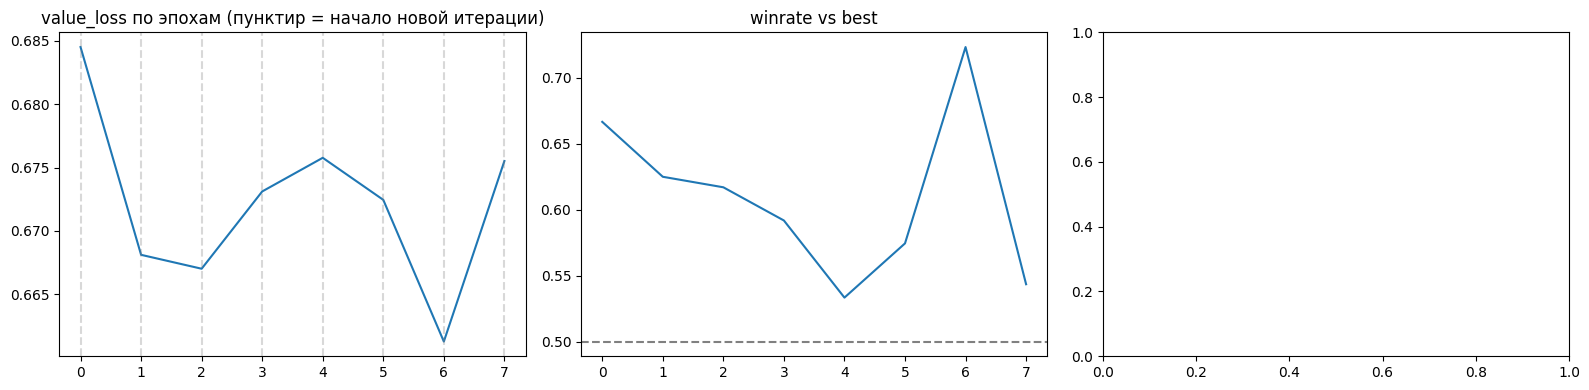

value_loss: train=0.6755  holdout=0.7159  разрыв=+0.0404
policy_loss: 1.9974
Winrate: 0.54
Accepted new best model: True

Iteration 9/15


In [ ]:
learner = Learner(
    buffer_size=100_000,
    buffer_n_samples=20_000,
    iterations=15,
    batch_size=512,
    epochs=1,
    n_games=500,
    arena_games=50,
    arena_temperature=0.5,
    threshold=0.5,
    c_puct=1.5,
    self_play_simulations=100,
    arena_simulations=50,
    preloaded_model_path="/kaggle/input/models/aurm36/model-iter-5/pytorch/default/1/iter5_wr0.5918367346938775",
    save_model_folder="/kaggle/working"
)


# old_params = [p.clone() for p in learner.best_model.parameters()]

learner.training_loop()


# for old, new in zip(old_params, learner.best_model.parameters()):
#     print(torch.allclose(old, new))

In [ ]:
rand_arena = Arena(
    learner.best_arena_agent,
    RandomAgent(),
    100
)
rand_arena.evaluate(is_random_model=True)